<a href="https://colab.research.google.com/github/khansa-020/Deep-Fake-Detection/blob/main/DeepFake_EfficientNetB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()


!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


**Deep Learning with Transfer Learning & Explainibility**

# DeepFake Detection Dataset
**Models:** Baseline CNN | InceptionV3 & DenseNet121 hybrid | InceptionV3 | **EfficientNetB3**\
**Framework:** PyTorch\
**Extras:** Grad-CAM Explainability on Best Model



---


# Section 1: Dataset Load & split

In [2]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip deepfake-and-real-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Validation/Real/real_5499.jpg  
  inflating: Dataset/Validation/Real/real_55.jpg  
  inflating: Dataset/Validation/Real/real_550.jpg  
  inflating: Dataset/Validation/Real/real_5500.jpg  
  inflating: Dataset/Validation/Real/real_5501.jpg  
  inflating: Dataset/Validation/Real/real_5502.jpg  
  inflating: Dataset/Validation/Real/real_5503.jpg  
  inflating: Dataset/Validation/Real/real_5504.jpg  
  inflating: Dataset/Validation/Real/real_5505.jpg  
  inflating: Dataset/Validation/Real/real_5506.jpg  
  inflating: Dataset/Validation/Real/real_5507.jpg  
  inflating: Dataset/Validation/Real/real_5508.jpg  
  inflating: Dataset/Validation/Real/real_5509.jpg  
  inflating: Dataset/Validation/Real/real_551.jpg  
  inflating: Dataset/Validation/Real/real_5510.jpg  
  inflating: Dataset/Validation/Real/real_5511.jpg  
  inflating: Dataset/Validation/Real/real_5512.jpg  
  inflating: Dataset/Validation/Real/real_5513.jpg  

In [3]:
import os

print("Train:", os.listdir("Dataset/Train"))
print("Validation:", os.listdir("Dataset/Validation"))
print("Test:", os.listdir("Dataset/Test"))

print("Real:", len(os.listdir("Dataset/Train/Real")))
print("Fake:", len(os.listdir("Dataset/Train/Fake")))

print("Real:", len(os.listdir("Dataset/Test/Real")))
print("Fake:", len(os.listdir("Dataset/Test/Fake")))

print("Real:", len(os.listdir("Dataset/Validation/Real")))
print("Fake:", len(os.listdir("Dataset/Validation/Fake")))

Train: ['Fake', 'Real']
Validation: ['Fake', 'Real']
Test: ['Fake', 'Real']
Real: 70001
Fake: 70001
Real: 5413
Fake: 5492
Real: 19787
Fake: 19641


In [4]:
import os
import random
import shutil

base_path = "Dataset"

train_real = os.path.join(base_path, "Train/Real")
train_fake = os.path.join(base_path, "Train/Fake")

val_real = os.path.join(base_path, "Validation/Real")
val_fake = os.path.join(base_path, "Validation/Fake")


output_base = "Subset_Dataset"

os.makedirs(output_base, exist_ok=True)

for split in ["train", "test", "val"]:
    for cls in ["Real", "Fake"]:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

In [5]:
real_images = os.listdir(train_real)
fake_images = os.listdir(train_fake)

real_sample = random.sample(real_images, 2500)
fake_sample = random.sample(fake_images, 2500)

for img in real_sample:
    shutil.copy(
        os.path.join(train_real, img),
        os.path.join(output_base, "train/Real", img)
    )

for img in fake_sample:
    shutil.copy(
        os.path.join(train_fake, img),
        os.path.join(output_base, "train/Fake", img)
    )

print("Real:", len(os.listdir("Subset_Dataset/train/Real")))
print("Fake:", len(os.listdir("Subset_Dataset/train/Fake")))
print("Train subset created ✔")

Real: 2500
Fake: 2500
Train subset created ✔


In [6]:
val_real_imgs = os.listdir(val_real)
val_fake_imgs = os.listdir(val_fake)

val_real_sample = random.sample(val_real_imgs, 500)
val_fake_sample = random.sample(val_fake_imgs, 500)

for img in val_real_sample:
    shutil.copy(
        os.path.join(val_real, img),
        os.path.join(output_base, "val/Real", img)
    )

for img in val_fake_sample:
    shutil.copy(
        os.path.join(val_fake, img),
        os.path.join(output_base, "val/Fake", img)
    )

print("Real:", len(os.listdir("Subset_Dataset/val/Real")))
print("Fake:", len(os.listdir("Subset_Dataset/val/Fake")))
print("Validation subset created ✔")


Real: 500
Fake: 500
Validation subset created ✔


In [7]:
import os
import shutil
from sklearn.model_selection import train_test_split

base = "Subset_Dataset"

# =========================
# PATHS
# =========================

train_real_path = os.path.join(base, "train/Real")
train_fake_path = os.path.join(base, "train/Fake")

# =========================
# CREATE OUTPUT FOLDERS
# =========================

os.makedirs(os.path.join(base, "final_train/Real"), exist_ok=True)
os.makedirs(os.path.join(base, "final_train/Fake"), exist_ok=True)

os.makedirs(os.path.join(base, "test/Real"), exist_ok=True)
os.makedirs(os.path.join(base, "test/Fake"), exist_ok=True)

# =========================
# LOAD IMAGE NAMES
# =========================

real_images = os.listdir(train_real_path)
fake_images = os.listdir(train_fake_path)

# =========================
# SPLIT REAL IMAGES
# =========================

train_real_imgs, test_real_imgs = train_test_split(
    real_images,
    test_size=0.2,
    random_state=42
)

# =========================
# SPLIT FAKE IMAGES
# =========================

train_fake_imgs, test_fake_imgs = train_test_split(
    fake_images,
    test_size=0.2,
    random_state=42
)

# =========================
# COPY TRAIN REAL
# =========================

for img in train_real_imgs:
    shutil.copy(
        os.path.join(train_real_path, img),
        os.path.join(base, "final_train/Real", img)
    )

# =========================
# COPY TRAIN FAKE
# =========================

for img in train_fake_imgs:
    shutil.copy(
        os.path.join(train_fake_path, img),
        os.path.join(base, "final_train/Fake", img)
    )

# =========================
# COPY TEST REAL
# =========================

for img in test_real_imgs:
    shutil.copy(
        os.path.join(train_real_path, img),
        os.path.join(base, "test/Real", img)
    )

# =========================
# COPY TEST FAKE
# =========================

for img in test_fake_imgs:
    shutil.copy(
        os.path.join(train_fake_path, img),
        os.path.join(base, "test/Fake", img)
    )

# =========================
# VERIFY COUNTS
# =========================

for split in ["final_train", "test", "val"]:
    print(f"\n{split.upper()}")

    for cls in ["Real", "Fake"]:
        path = os.path.join(base, split, cls)
        print(cls, ":", len(os.listdir(path)))


FINAL_TRAIN
Real : 2000
Fake : 2000

TEST
Real : 500
Fake : 500

VAL
Real : 500
Fake : 500


# Section 2: Imports & Dataset Preprocessing

In [8]:
# ──INSTALLS────────────────────────────────────────────────────
!pip install timm -q

# ── IMPORTS────────────────────────────────────────────────────
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import timm

warnings.filterwarnings("ignore")

# ──Reproducibility- SEED────────────────────────────────────────
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── DEVICE ─────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cpu


Train: 4000
Val: 1000
Test: 1000


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Total Parameters: 10,901,354
Trainable Parameters: 8,118,304

Epoch [1/10]


100%|██████████| 125/125 [02:09<00:00,  1.03s/it]


Epoch | TrainLoss 0.4950 | TrainAcc 0.8035 | ValLoss 0.3887 | ValAcc 0.8890 | TestLoss 0.3584 | TestAcc 0.9010 | LR 0.000098 | Best Model Saved

Epoch [2/10]


...

Epoch | TrainLoss 0.2411 | TrainAcc 0.9775 | ValLoss 0.3280 | ValAcc 0.9370 | TestLoss 0.2793 | TestAcc 0.9520 | LR 0.000002 | 

Epoch [10/10]


100%|██████████| 125/125 [02:10<00:00,  1.04s/it]


Epoch | TrainLoss 0.2351 | TrainAcc 0.9830 | ValLoss 0.3144 | ValAcc 0.9380 | TestLoss 0.2785 | TestAcc 0.9510 | LR 0.000000 | Best Model Saved

Training Time: 226.99 minutes


100%|██████████| 125/125 [02:14<00:00,  1.08s/it]




CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake     0.9501    0.9520    0.9510       500
        Real     0.9519    0.9500    0.9510       500

    accuracy                         0.9510      1000
   macro avg     0.9510    0.9510    0.9510      1000
weighted avg     0.9510    0.9510    0.9510      1000


SET PERFORMANCE REPORT

Accuracy          : 95.10%
F1 (Macro)        : 0.9510
F1 (Weighted)     : 0.9510
Precision (W)     : 0.9510
Recall (W)        : 0.9510
ROC-AUC (macro)   : 0.9882
Test Loss         : 0.2785




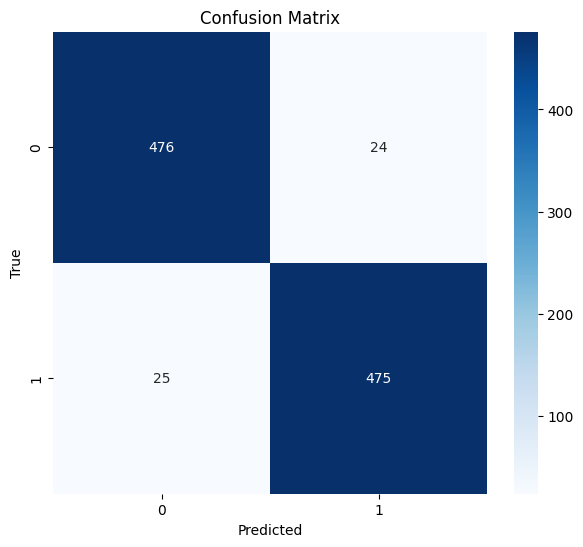

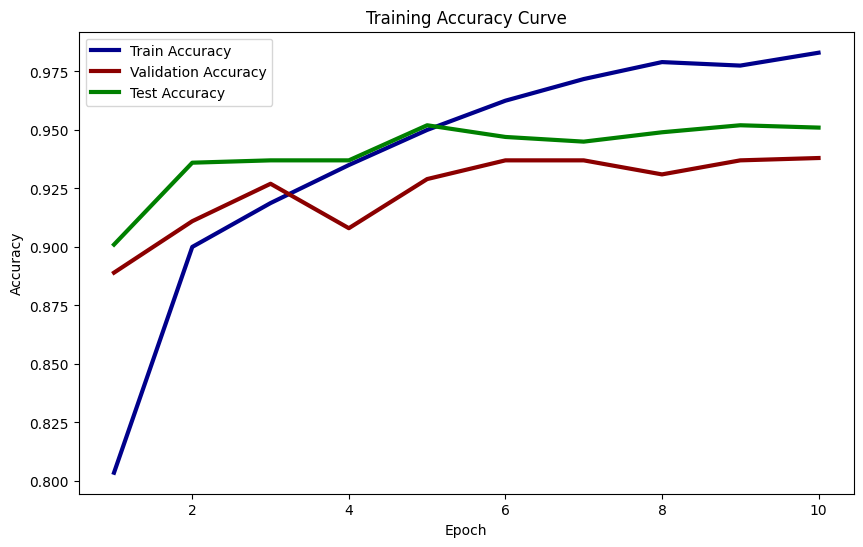

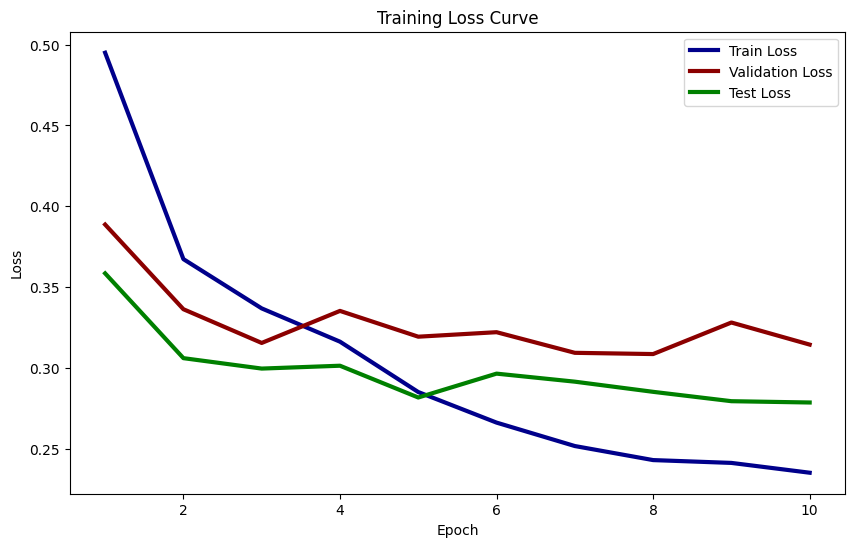


ALL FILES SAVED SUCCESSFULLY
/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake


In [16]:
#  SAVE DIRECTORIES────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake"

os.makedirs(SAVE_DIR, exist_ok=True)


MODEL_DIR      = os.path.join(SAVE_DIR, "models")
CHECKPOINT_DIR = os.path.join(SAVE_DIR, "checkpoints")
LOG_DIR        = os.path.join(SAVE_DIR, "logs")
PLOT_DIR       = os.path.join(SAVE_DIR, "plots")
INFER_DIR      = os.path.join(SAVE_DIR, "inference")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(INFER_DIR, exist_ok=True)

# ============================================================
# 6. DATASET PATHS
# ============================================================
TRAIN_DIR = "/content/Subset_Dataset/final_train"
VAL_DIR   = "/content/Subset_Dataset/val"
TEST_DIR  = "/content/Subset_Dataset/test"

# ============================================================
# 7. HYPERPARAMETERS (Paper-Based)
# ============================================================
IMAGE_SIZE = 224

BATCH_SIZE = 8
EPOCHS = 10

LR = 1e-4
WEIGHT_DECAY = 1e-4

NUM_CLASSES = 2

DROPOUT = 0.3

LABEL_SMOOTHING = 0.1

WARMUP_EPOCHS = 1

MIXED_PRECISION = True

PATCH_SIZE = "N/A (CNN Based)"

HIDDEN_LAYER = [128, 64]

CLASSIFICATION_LAYER = "Sigmoid"

LAYERS_NO = 3

ACTIVATION_FUNCTION = "ReLU"

POOLING = "AdaptiveAvgPool2d"

FILTERS = "EfficientNet-B3 Default"

# ============================================================
# 8. TRANSFORMS (Exact Paper)
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# 9. DATASETS
# ============================================================
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset  = ImageFolder(TEST_DIR, transform=val_test_transform)

# ============================================================
# 10. DATALOADERS
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

# ============================================================
# 11. MODEL
# ============================================================
class EfficientNetB3DeepFake(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=True,
            num_classes=0
        )

        in_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = EfficientNetB3DeepFake().to(DEVICE)

# ============================================================
# 12. FREEZE LOWER LAYERS (Transfer Learning)
# ============================================================
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last blocks
for param in model.backbone.blocks[-2:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# ============================================================
# 13. PARAMETERS
# ============================================================
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# ============================================================
# 14. LOSS
# ============================================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

# ============================================================
# 15. OPTIMIZER
# ============================================================
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# ============================================================
# 16. SCHEDULER
# ============================================================
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ============================================================
# 17. MIXED PRECISION
# ============================================================
scaler = GradScaler(enabled=MIXED_PRECISION)

# ============================================================
# 18. TRAIN FUNCTION
# ============================================================
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    preds_all = []
    labels_all = []

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=MIXED_PRECISION):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)

    return running_loss / len(loader), acc

# ============================================================
# 19. EVALUATION FUNCTION
# ============================================================
def evaluate(model, loader):

    model.eval()

    running_loss = 0

    preds_all = []
    labels_all = []

    logits_all = []
    probs_all = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item()

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

            logits_all.extend(outputs.cpu().numpy())
            probs_all.extend(probs[:,1].cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)

    return (
        running_loss / len(loader),
        acc,
        labels_all,
        preds_all,
        logits_all,
        probs_all
    )

# ============================================================
# 20. TRAINING LOOP
# ============================================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "test_loss": [],
    "test_acc": [],
    "lr": []
}

best_acc = 0

start_time = time.time()

for epoch in range(EPOCHS):

    print("\n" + "="*70)
    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print("="*70)

    train_loss, train_acc = train_one_epoch(model, train_loader)

    val_loss, val_acc, _, _, _, _ = evaluate(model, val_loader)

    test_loss, test_acc, _, _, _, _ = evaluate(model, test_loader)

    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    history["lr"].append(current_lr)

    note = ""

    # Save Best
    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "best_model.pth")
        )

        note = "Best Model Saved"

    # Checkpoint
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            f"checkpoint_epoch_{epoch+1}.pth"
        )
    )

    print(
        f"Epoch | "
        f"TrainLoss {train_loss:.4f} | "
        f"TrainAcc {train_acc:.4f} | "
        f"ValLoss {val_loss:.4f} | "
        f"ValAcc {val_acc:.4f} | "
        f"TestLoss {test_loss:.4f} | "
        f"TestAcc {test_acc:.4f} | "
        f"LR {current_lr:.6f} | "
        f"{note}"
    )

total_time = time.time() - start_time

print(f"\nTraining Time: {total_time/60:.2f} minutes")

# ============================================================
# 21. SAVE TRAINING LOGS
# ============================================================
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(LOG_DIR, "training_logs.csv"),
    index=False
)

# ============================================================
# 22. LOAD BEST MODEL
# ============================================================
model.load_state_dict(
    torch.load(
        os.path.join(MODEL_DIR, "best_model.pth")
    )
)

# ============================================================
# 23. FINAL EVALUATION
# ============================================================
test_loss, test_acc, y_true, y_pred, logits, probs = evaluate(
    model,
    test_loader
)

# ============================================================
# 24. SAVE LOGITS + INFERENCE
# ============================================================
infer_df = pd.DataFrame({
    "TrueLabel": y_true,
    "Predicted": y_pred,
    "ProbabilityFake": probs
})

infer_df.to_csv(
    os.path.join(INFER_DIR, "inference_results.csv"),
    index=False
)

np.save(
    os.path.join(INFER_DIR, "logits.npy"),
    np.array(logits)
)

# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    digits=4
)

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(report)

with open(
    os.path.join(LOG_DIR, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

# ============================================================
# 26. PERFORMANCE REPORT
# ============================================================
accuracy = accuracy_score(y_true, y_pred)

f1_macro = f1_score(y_true, y_pred, average='macro')

f1_weighted = f1_score(y_true, y_pred, average='weighted')

precision_weighted = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

roc_auc = roc_auc_score(y_true, probs)

performance = f"""
==================================================
SET PERFORMANCE REPORT
==================================================

Accuracy          : {accuracy*100:.2f}%
F1 (Macro)        : {f1_macro:.4f}
F1 (Weighted)     : {f1_weighted:.4f}
Precision (W)     : {precision_weighted:.4f}
Recall (W)        : {recall_weighted:.4f}
ROC-AUC (macro)   : {roc_auc:.4f}
Test Loss         : {test_loss:.4f}

==================================================
"""

print(performance)

with open(
    os.path.join(LOG_DIR, "performance_report.txt"),
    "w"
) as f:
    f.write(performance)

# ============================================================
# 27. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 28. TRAINING CURVES
# ============================================================
epochs_range = range(1, EPOCHS + 1)

# Accuracy Curve
plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    history["train_acc"],
    color='darkblue',
    linewidth=3,
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    history["val_acc"],
    color='darkred',
    linewidth=3,
    label='Validation Accuracy'
)

plt.plot(
    epochs_range,
    history["test_acc"],
    color='green',
    linewidth=3,
    label='Test Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()
plt.grid(False)

plt.savefig(
    os.path.join(PLOT_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 29. LOSS CURVE
# ============================================================
plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    history["train_loss"],
    color='darkblue',
    linewidth=3,
    label='Train Loss'
)

plt.plot(
    epochs_range,
    history["val_loss"],
    color='darkred',
    linewidth=3,
    label='Validation Loss'
)

plt.plot(
    epochs_range,
    history["test_loss"],
    color='green',
    linewidth=3,
    label='Test Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(False)

plt.savefig(
    os.path.join(PLOT_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 30. SAVE HYPERPARAMETERS
# ============================================================
hyperparameters = {

    "Model": "EfficientNet-B3",

    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,

    "Image Size": IMAGE_SIZE,
    "Patch Size": PATCH_SIZE,

    "Batch Size": BATCH_SIZE,

    "Hidden Layer": HIDDEN_LAYER,

    "Classification Layer": CLASSIFICATION_LAYER,

    "fully connected Layers Number": LAYERS_NO,

    "Activation Function": ACTIVATION_FUNCTION,

    "Learning Rate": LR,

    "Optimizer": "AdamW",

    "Scheduler": "CosineAnnealingLR",

    "Pooling": POOLING,

    "Filter": FILTERS,

    "Dropout": DROPOUT,

    "Warmup Epochs": WARMUP_EPOCHS,

    "Weight Decay": WEIGHT_DECAY,

    "Label Smoothing": LABEL_SMOOTHING,

    "Mixed Precision FP16": MIXED_PRECISION,

    "Total Epochs": EPOCHS,

    "Loss Function": "CrossEntropyLoss"
}

with open(
    os.path.join(LOG_DIR, "hyperparameters.json"),
    "w"
) as f:
    json.dump(hyperparameters, f, indent=4)

print("\nALL FILES SAVED SUCCESSFULLY")
print(SAVE_DIR)

In [22]:
    from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [21]:
!rm -rf /content/drive

In [47]:
!ls /content/drive/MyDrive/

'0-S&M Methods for DS Formula Sheet.gdoc'
 1-s2.0-S0957417425024613-main.gdoc
 Classroom
'Colab Notebooks'
'Comparitive Analysis of ML & DL on DeepFake'
'Copy of Final Project Github Repo.gsheet'
'CV kh FR.pdf'
'Khansa - dataset.gsheet'
'KHANSA IT.pdf'
 my.jpg
'Truck Assignment Automation'
 ViT_Medical_FineTuning
'What is Riba (Interest) in Islam, and Why is it Strictly Prohibited? A Critical and Analytical Study in the Light of Qur’an, Sunnah, and Contemporary Economic Systems.gdoc'
'Z-Table & T-Table.gdoc'


In [35]:
import os

SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake"

print("Exists:", os.path.exists(SAVE_DIR))

for root, dirs, files in os.walk(SAVE_DIR):
    print(f"\n{root}")
    for file in files:
        print(file)

Exists: True

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/models

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/checkpoints

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/logs
training_logs.csv

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/plots

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/inference


100%|██████████| 125/125 [02:07<00:00,  1.02s/it]




CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake     0.9501    0.9520    0.9510       500
        Real     0.9519    0.9500    0.9510       500

    accuracy                         0.9510      1000
   macro avg     0.9510    0.9510    0.9510      1000
weighted avg     0.9510    0.9510    0.9510      1000


SET PERFORMANCE REPORT

Accuracy          : 95.10%
F1 (Macro)        : 0.9510
F1 (Weighted)     : 0.9510
Precision (W)     : 0.9510
Recall (W)        : 0.9510
ROC-AUC (macro)   : 0.9882
Test Loss         : 0.2785




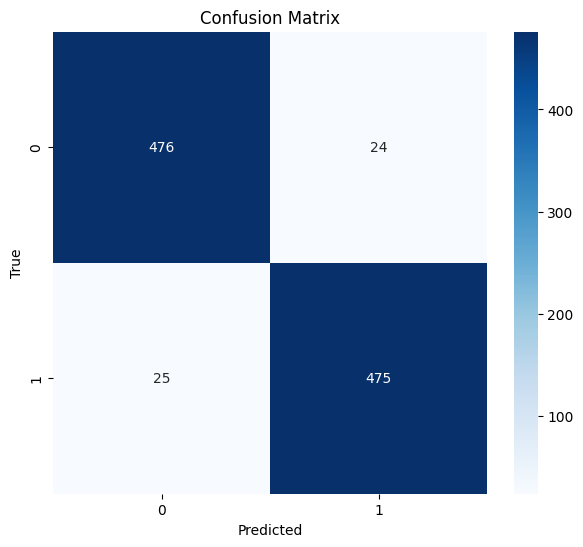

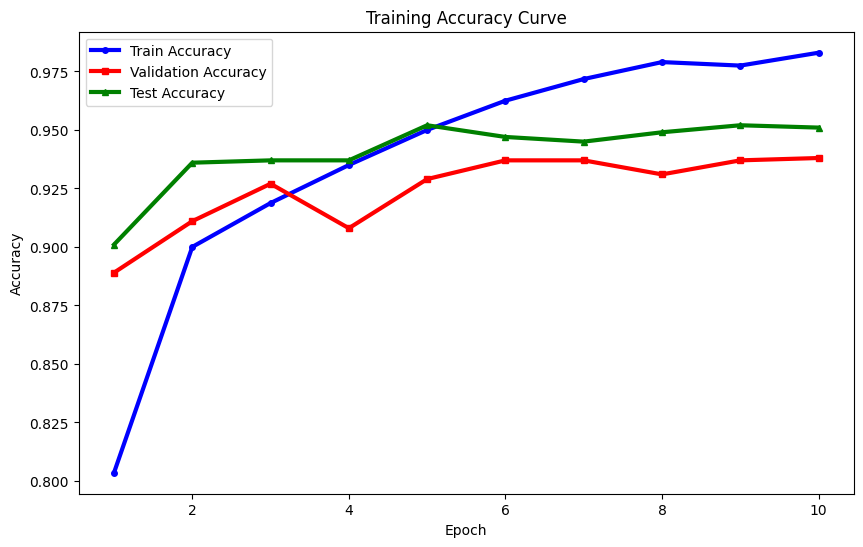

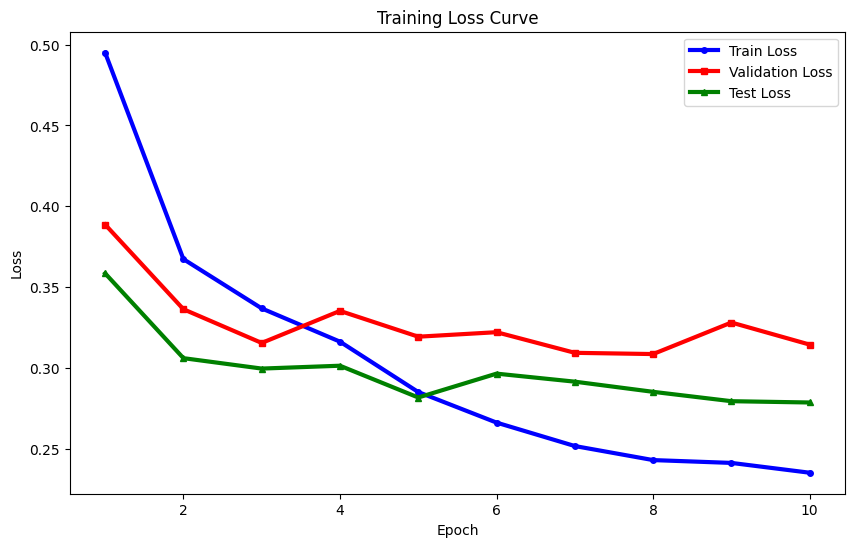


ALL FILES SAVED SUCCESSFULLY
/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake


In [43]:

#  SAVE DIRECTORIES────────────────────────────────
SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake"

os.makedirs(SAVE_DIR, exist_ok=True)


MODEL_DIR      = os.path.join(SAVE_DIR, "models")
CHECKPOINT_DIR = os.path.join(SAVE_DIR, "checkpoints")
LOG_DIR        = os.path.join(SAVE_DIR, "logs")
PLOT_DIR       = os.path.join(SAVE_DIR, "plots")
INFER_DIR      = os.path.join(SAVE_DIR, "inference")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(INFER_DIR, exist_ok=True)


# ============================================================
# 21. SAVE TRAINING LOGS
# ============================================================
history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(LOG_DIR, "training_logs.csv"),
    index=False
)

# # ============================================================
# # 22. LOAD BEST MODEL
# # ============================================================
# model.load_state_dict(
#     torch.load(
#         os.path.join(MODEL_DIR, "best_model.pth")
#     )
# )

# # ============================================================
# # 23. FINAL EVALUATION
# # ============================================================
test_loss, test_acc, y_true, y_pred, logits, probs = evaluate(
    model,
    test_loader
)

# # ============================================================
# # 24. SAVE LOGITS + INFERENCE
# # ============================================================
infer_df = pd.DataFrame({
    "TrueLabel": y_true,
    "Predicted": y_pred,
    "ProbabilityFake": probs
})

infer_df.to_csv(
    os.path.join(INFER_DIR, "inference_results.csv"),
    index=False
)

np.save(
    os.path.join(INFER_DIR, "logits.npy"),
    np.array(logits)
)

# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.classes,
    digits=4
)

print("\n")
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(report)

with open(
    os.path.join(LOG_DIR, "classification_report.txt"),
    "w"
) as f:
    f.write(report)

# ============================================================
# 26. PERFORMANCE REPORT
# ============================================================
accuracy = accuracy_score(y_true, y_pred)

f1_macro = f1_score(y_true, y_pred, average='macro')

f1_weighted = f1_score(y_true, y_pred, average='weighted')

precision_weighted = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

roc_auc = roc_auc_score(y_true, probs)

performance = f"""
==================================================
SET PERFORMANCE REPORT
==================================================

Accuracy          : {accuracy*100:.2f}%
F1 (Macro)        : {f1_macro:.4f}
F1 (Weighted)     : {f1_weighted:.4f}
Precision (W)     : {precision_weighted:.4f}
Recall (W)        : {recall_weighted:.4f}
ROC-AUC (macro)   : {roc_auc:.4f}
Test Loss         : {test_loss:.4f}

==================================================
"""

print(performance)

with open(
    os.path.join(LOG_DIR, "performance_report.txt"),
    "w"
) as f:
    f.write(performance)

# ============================================================
# 27. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 28. TRAINING CURVES
# ============================================================
epochs_range = range(1, EPOCHS + 1)

# Accuracy Curve
plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    history["train_acc"],
    color='blue',
    marker='o',
    markersize=4,
    linewidth=3,
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    history["val_acc"],
    marker='s',
    color='red',
    markersize=4,
    linewidth=3,
    label='Validation Accuracy'
)

plt.plot(
    epochs_range,
    history["test_acc"],
    color='green',
    marker='^',
    markersize=4,
    linewidth=3,
    label='Test Accuracy'
)
# plt.ylim(60, 95)
# plt.yticks(np.arange(60, 96, 5))

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()
plt.grid(False)

plt.savefig(
    os.path.join(PLOT_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 29. LOSS CURVE
# ============================================================
plt.figure(figsize=(10,6))

plt.plot(
    epochs_range,
    history["train_loss"],
    color='blue',
    marker='o',
    markersize=4,
    linewidth=3,
    label='Train Loss'
)

plt.plot(
    epochs_range,
    history["val_loss"],
    color='red',
    marker='s',
    markersize=4,
    linewidth=3,
    label='Validation Loss'
)

plt.plot(
    epochs_range,
    history["test_loss"],
    color='green',
    marker='^',
    markersize=4,
    linewidth=3,
    label='Test Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(False)

plt.savefig(
    os.path.join(PLOT_DIR, "loss_curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 30. SAVE HYPERPARAMETERS
# ============================================================
hyperparameters = {

    "Model": "EfficientNet-B3",

    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,

    "Image Size": IMAGE_SIZE,
    "Patch Size": PATCH_SIZE,

    "Batch Size": BATCH_SIZE,

    "Hidden Layer": HIDDEN_LAYER,

    "Classification Layer": CLASSIFICATION_LAYER,

    "fully connected Layers Number": LAYERS_NO,

    "Activation Function": ACTIVATION_FUNCTION,

    "Learning Rate": LR,

    "Optimizer": "AdamW",

    "Scheduler": "CosineAnnealingLR",

    "Pooling": POOLING,

    "Filter": FILTERS,

    "Dropout": DROPOUT,

    "Warmup Epochs": WARMUP_EPOCHS,

    "Weight Decay": WEIGHT_DECAY,

    "Label Smoothing": LABEL_SMOOTHING,

    "Mixed Precision FP16": MIXED_PRECISION,

    "Total Epochs": EPOCHS,

    "Loss Function": "CrossEntropyLoss"
}

with open(
    os.path.join(LOG_DIR, "hyperparameters.json"),
    "w"
) as f:
    json.dump(hyperparameters, f, indent=4)

print("\nALL FILES SAVED SUCCESSFULLY")
print(SAVE_DIR)

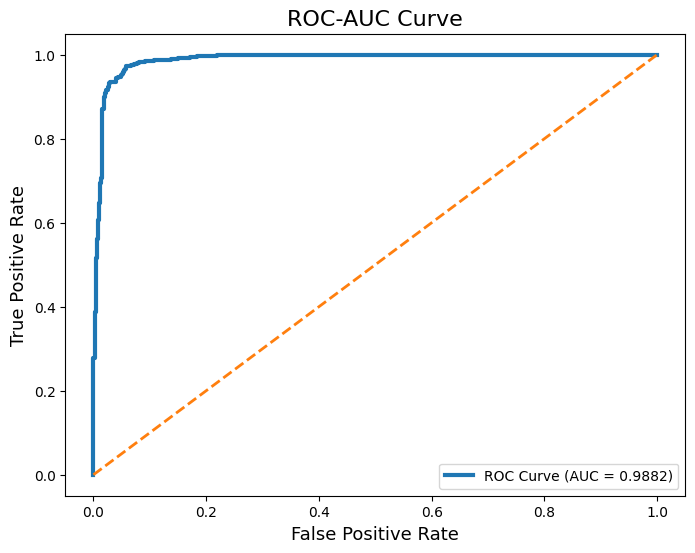

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/plots/roc_auc_curve.png


100%|██████████| 125/125 [02:13<00:00,  1.07s/it]


Feature Shape: (1000, 1536)


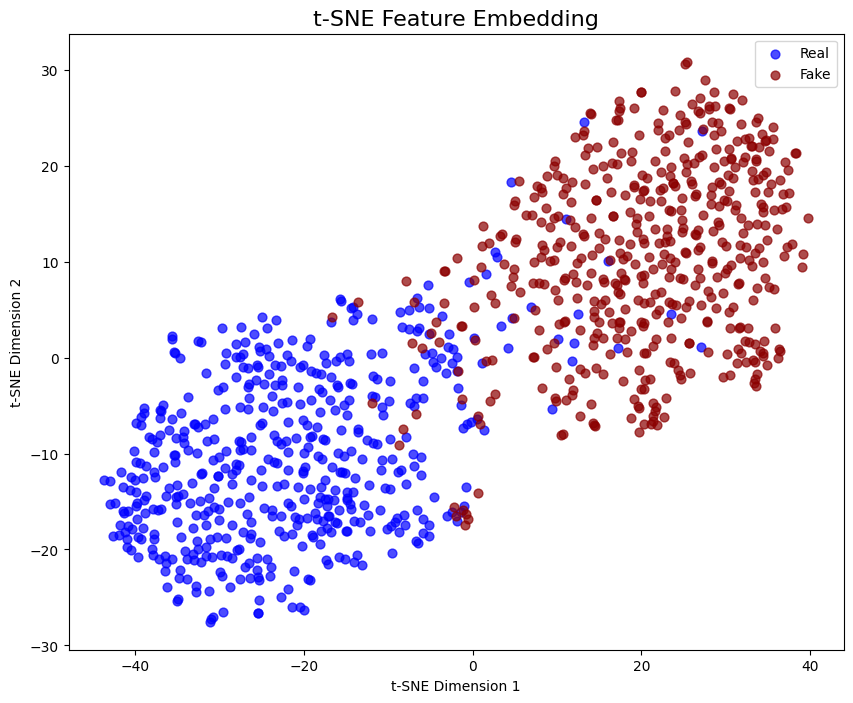

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/plots/tsne_visualization.png


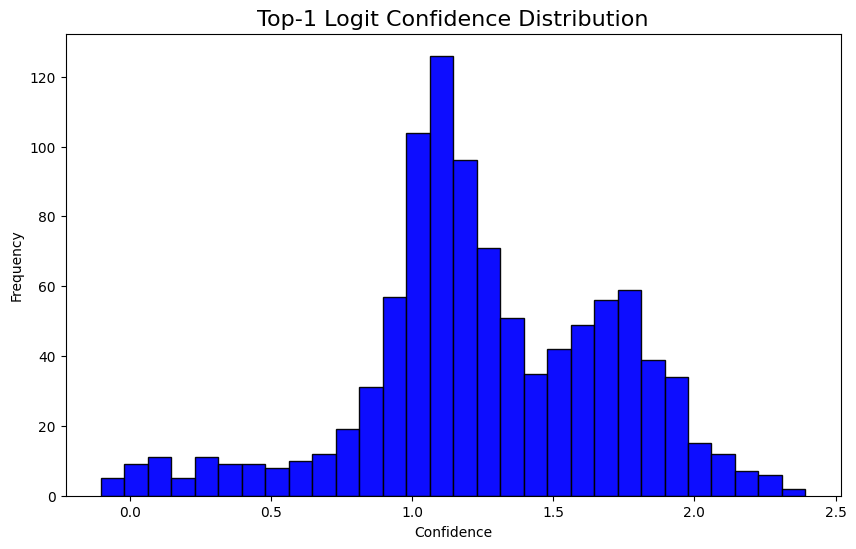

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/plots/top1_confidence_distribution.png


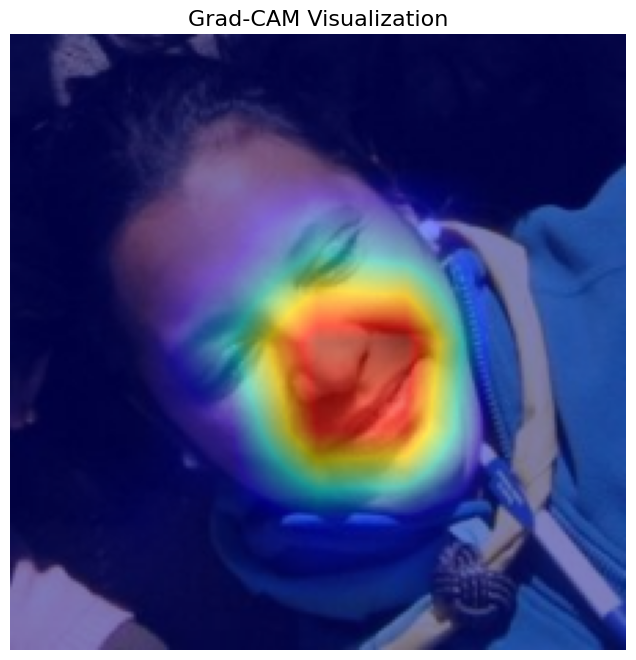

Saved: /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/plots/gradcam_visualization.png

ALL ADVANCED VISUALIZATIONS SAVED
/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/plots


In [48]:
# ROC-AUC | TSNE | GRAD-CAM | VISUALIZATIONS
# ============================================================
!pip install grad-cam -q

# ============================================================
# 2. IMPORTS
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import cv2

# ============================================================
# 3. WHITE BACKGROUND STYLE
# ============================================================
plt.style.use('default')

# ============================================================
# 4. ROC CURVE
# ============================================================
fpr, tpr, thresholds = roc_curve(y_true, probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6), facecolor='white')

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2
)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)

plt.title('ROC-AUC Curve', fontsize=16)

plt.legend()

plt.grid(False)

roc_path = os.path.join(PLOT_DIR, "roc_auc_curve.png")

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved:", roc_path)

# ============================================================
# 5. FEATURE EXTRACTION FOR TSNE
# ============================================================
model.eval()

features = []
labels_tsne = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        feat = model.backbone(images)

        features.append(feat.cpu().numpy())

        labels_tsne.extend(labels.numpy())

features = np.concatenate(features, axis=0)

print("Feature Shape:", features.shape)

# ============================================================
# 6. PCA BEFORE TSNE (Faster)
# ============================================================
pca = PCA(n_components=50, random_state=SEED)

features_pca = pca.fit_transform(features)

# ============================================================
# 7. TSNE
# ============================================================
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='random',
    random_state=SEED
)

tsne_result = tsne.fit_transform(features_pca)

# ============================================================
# 8. TSNE VISUALIZATION
# ============================================================
plt.figure(figsize=(10, 8), facecolor='white')

for label in np.unique(labels_tsne):

    idx = np.array(labels_tsne) == label

    if label == 0:
        name = "Real"
        color = "blue"
    else:
        name = "Fake"
        color = "darkred"

    plt.scatter(
        tsne_result[idx, 0],
        tsne_result[idx, 1],
        label=name,
        alpha=0.7,
        s=40,
        c=color,
        cmap='coolwarm',
    )

plt.title("t-SNE Feature Embedding", fontsize=16)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend()

plt.grid(False)

tsne_path = os.path.join(PLOT_DIR, "tsne_visualization.png")

plt.savefig(
    tsne_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved:", tsne_path)

# # ============================================================
# # 9. FEATURE CORRELATION MATRIX
# # ============================================================
# feature_df = pd.DataFrame(features_pca[:, :20])

# corr_matrix = feature_df.corr()

# plt.figure(figsize=(12, 10), facecolor='white')

# sns.heatmap(
#     corr_matrix,
#     cmap='Blues',
#     square=True,
#     cbar=True
# )

# plt.title("Feature Correlation Matrix", fontsize=16)

# feature_matrix_path = os.path.join(
#     PLOT_DIR,
#     "feature_correlation_matrix.png"
# )

# plt.savefig(
#     feature_matrix_path,
#     dpi=300,
#     bbox_inches='tight',
#     facecolor='white'
# )

# plt.show()

# print("Saved:", feature_matrix_path)

# ============================================================
# 10. TOP-1 CONFIDENCE DISTRIBUTION
# ============================================================
top1_confidence = np.max(
    np.array(logits),
    axis=1
)

plt.figure(figsize=(10, 6), facecolor='white')

plt.hist(
    top1_confidence,
    bins=30,
    color='blue',
    edgecolor='black',
    alpha=0.95
)

plt.title("Top-1 Logit Confidence Distribution", fontsize=16)

plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.grid(False)

top1_path = os.path.join(
    PLOT_DIR,
    "top1_confidence_distribution.png"
)

plt.savefig(
    top1_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved:", top1_path)

# ============================================================
# 11. GRAD-CAM
# ============================================================

# Target Layer
target_layer = model.backbone.blocks[-1]

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

# ============================================================
# 12. GET SAMPLE IMAGE
# ============================================================
sample_image, sample_label = test_dataset[0]

input_tensor = sample_image.unsqueeze(0).to(DEVICE)

# ============================================================
# 13. GENERATE CAM
# ============================================================
grayscale_cam = cam(
    input_tensor=input_tensor
)

grayscale_cam = grayscale_cam[0]

# ============================================================
# 14. DENORMALIZE IMAGE
# ============================================================
image_np = sample_image.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = std * image_np + mean

image_np = np.clip(image_np, 0, 1)

# ============================================================
# 15. OVERLAY HEATMAP
# ============================================================
visualization = show_cam_on_image(
    image_np.astype(np.float32),
    grayscale_cam,
    use_rgb=True
)

# ============================================================
# 16. SAVE GRADCAM
# ============================================================
gradcam_path = os.path.join(
    PLOT_DIR,
    "gradcam_visualization.png"
)

plt.figure(figsize=(8, 8), facecolor='white')

plt.imshow(visualization)

plt.title("Grad-CAM Visualization", fontsize=16)

plt.axis('off')

plt.savefig(
    gradcam_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved:", gradcam_path)

# ============================================================
# 17. SAVE FEATURE EMBEDDINGS
# ============================================================
np.save(
    os.path.join(INFER_DIR, "features.npy"),
    features
)

np.save(
    os.path.join(INFER_DIR, "tsne_embeddings.npy"),
    tsne_result
)

# ============================================================
# 18. SAVE ALL VISUALIZATION METADATA
# ============================================================
visualization_report = {
    "ROC_AUC": float(roc_auc),
    "TSNE_Samples": int(len(tsne_result)),
    # "Feature_Vector_Dimension": int(features.shape[1]),
    # "Feature_Correlation_Matrix_Size": str(corr_matrix.shape),
    "GradCAM_Target_Layer": str(target_layer)
}

with open(
    os.path.join(LOG_DIR, "visualization_report.json"),
    "w"
) as f:
    json.dump(visualization_report, f, indent=4)

print("\nALL ADVANCED VISUALIZATIONS SAVED")
print(PLOT_DIR)

In [49]:
# ============================================================
# INFERENCE ON CHATGPT / GEMINI GENERATED IMAGES
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# ============================================================
# 2. CLASS NAMES
# ============================================================
# Change if your folder labels differ
CLASS_NAMES = ['real', 'fake']

# ============================================================
# 3. LOAD BEST MODEL
# ============================================================
model = EfficientNetB3DeepFake().to(DEVICE)

model.load_state_dict(
    torch.load(
        os.path.join(MODEL_DIR, "best_model.pth"),
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully")

# ============================================================
# 4. INFERENCE TRANSFORM
# SAME AS PAPER
# ============================================================
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# 5. IMAGE PATHS
# ============================================================
# Upload your ChatGPT / Gemini generated images to Colab

IMAGE_1 = "/content/chatgpt_image.png"
IMAGE_2 = "/content/gemini_image.png"

image_paths = [IMAGE_1, IMAGE_2]

# ============================================================
# 6. PREDICTION FUNCTION
# ============================================================
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    original_image = image.copy()

    image_tensor = inference_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

    predicted_class = CLASS_NAMES[prediction.item()]

    confidence_score = confidence.item()

    logits = outputs.cpu().numpy()[0]

    return {
        "image": original_image,
        "prediction": predicted_class,
        "confidence": confidence_score,
        "logits": logits,
        "probabilities": probabilities.cpu().numpy()[0]
    }

# ============================================================
# 7. RUN INFERENCE
# ============================================================
results = []

for path in image_paths:

    result = predict_image(path)

    results.append(result)

# ============================================================
# 8. VISUALIZE PREDICTIONS
# ============================================================
plt.figure(figsize=(12, 6), facecolor='white')

for idx, result in enumerate(results):

    plt.subplot(1, len(results), idx + 1)

    plt.imshow(result["image"])

    pred = result["prediction"].upper()

    conf = result["confidence"] * 100

    plt.title(
        f"Prediction: {pred}\nConfidence: {conf:.2f}%",
        fontsize=13,
        color='darkblue'
    )

    plt.axis("off")

plt.tight_layout()

# ============================================================
# 9. SAVE VISUALIZATION
# ============================================================
inference_plot_path = os.path.join(
    INFER_DIR,
    "chatgpt_gemini_predictions.png"
)

plt.savefig(
    inference_plot_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved:", inference_plot_path)

# ============================================================
# 10. PRINT DETAILED RESULTS
# ============================================================
print("\n" + "="*70)
print("INFERENCE RESULTS")
print("="*70)

for idx, result in enumerate(results):

    print(f"\nIMAGE {idx+1}")

    print("-"*50)

    print(f"Prediction      : {result['prediction']}")

    print(f"Confidence      : {result['confidence']*100:.2f}%")

    print(f"Logits          : {result['logits']}")

    print(f"Probabilities   : {result['probabilities']}")

# ============================================================
# 11. SAVE RESULTS
# ============================================================
import pandas as pd

rows = []

for idx, result in enumerate(results):

    rows.append({
        "Image": image_paths[idx],
        "Prediction": result["prediction"],
        "Confidence": result["confidence"],
        "Logit_Real": result["logits"][0],
        "Logit_Fake": result["logits"][1],
        "Prob_Real": result["probabilities"][0],
        "Prob_Fake": result["probabilities"][1]
    })

results_df = pd.DataFrame(rows)

results_csv_path = os.path.join(
    INFER_DIR,
    "chatgpt_gemini_inference.csv"
)

results_df.to_csv(
    results_csv_path,
    index=False
)

print("\nInference CSV saved:")
print(results_csv_path)

# ============================================================
# 12. OPTIONAL SINGLE IMAGE TEST
# ============================================================
# Example:
#
# single_result = predict_image("/content/test_image.png")
#
# print(single_result)
#
# ============================================================

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/efficientNetB3_DeepFake/models/best_model.pth'